In [0]:
sc = spark.sparkContext

In [0]:
spark 

SparkSession - hive 
 
 
 SparkContext 

 Spark UI 

 
 Version 
 v3.3.2 
 Master 
 local[8] 
 AppName 
 Databricks Shell

In [0]:
import pandas as pd
from pyspark.sql.functions import col
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql.functions import col, when, regexp_extract
from pyspark import StorageLevel
import matplotlib.pyplot as plt
import seaborn as sns

In [0]:
# Read the file into a Spark DataFrame
df_spark = spark.read.csv("/FileStore/tables/googleplaystore.csv", header=True, inferSchema=True)
df = df_spark.toPandas()
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [0]:
# Count the number of rows
num_rows = df_spark.count()
# Get the number of columns
num_columns = len(df_spark.columns)
print("Number of Rows:", num_rows)
print("Number of Columns:", num_columns)

Number of Rows: 10841
Number of Columns: 13


In [0]:
df_spark.show()

+--------------------+--------------+------+-------+----+-----------+----+-----+--------------+--------------------+------------------+------------------+------------+
|                 App|      Category|Rating|Reviews|Size|   Installs|Type|Price|Content Rating|              Genres|      Last Updated|       Current Ver| Android Ver|
+--------------------+--------------+------+-------+----+-----------+----+-----+--------------+--------------------+------------------+------------------+------------+
|Photo Editor & Ca...|ART_AND_DESIGN|   4.1|    159| 19M|    10,000+|Free|    0|      Everyone|        Art & Design|   January 7, 2018|             1.0.0|4.0.3 and up|
| Coloring book moana|ART_AND_DESIGN|   3.9|    967| 14M|   500,000+|Free|    0|      Everyone|Art & Design;Pret...|  January 15, 2018|             2.0.0|4.0.3 and up|
|U Launcher Lite –...|ART_AND_DESIGN|   4.7|  87510|8.7M| 5,000,000+|Free|    0|      Everyone|        Art & Design|    August 1, 2018|             1.2.4|4.0.3 

In [0]:
df_spark.printSchema()

root
 |-- App: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Rating: string (nullable = true)
 |-- Reviews: string (nullable = true)
 |-- Size: string (nullable = true)
 |-- Installs: string (nullable = true)
 |-- Type: string (nullable = true)
 |-- Price: string (nullable = true)
 |-- Content Rating: string (nullable = true)
 |-- Genres: string (nullable = true)
 |-- Last Updated: string (nullable = true)
 |-- Current Ver: string (nullable = true)
 |-- Android Ver: string (nullable = true)



In [0]:
# Define the new column names with lowercased and underscored names
new_column_names = [col(col_name).alias(col_name.lower().replace(' ', '_')) for col_name in df_spark.columns]

# Select the DataFrame with the new column names
df_spark = df_spark.select(*new_column_names)

In [0]:
print('Columns overview')
pd.DataFrame(df_spark.dtypes, columns = ['Column Name','Data type'])

Columns overview


,Column Name,Data type
0,app,string
1,category,string
2,rating,string
3,reviews,string
4,size,string
5,installs,string
6,type,string
7,price,string
8,content_rating,string
9,genres,string


In [0]:
# Find duplicate rows based on the 'app' column
#duplicate_rows = df_spark.groupBy('app').count().filter('count > 1')
# Drop duplicate rows based on the 'app' column
df_spark = df_spark.dropDuplicates(['app'])

In [0]:
df_spark.count()

Out[11]: 9660

In [0]:
# Checking Null Values in each column using count() and when() functions
col_null_cnt_df =  df_spark.select([count(when(col(c).isNull(),c)).alias(c) for c in df_spark.columns])
display(col_null_cnt_df)

app,category,rating,reviews,size,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver
0,0,0,0,0,0,0,0,1,0,0,1,1


In [0]:
# Drop rows with any null value
df_spark = df_spark.dropna()

In [0]:
#Checking the size after dropping null values
#Count the number of rows
num_rows = df_spark.count()
# Get the number of columns
num_columns = len(df_spark.columns)
print("Number of Rows:", num_rows)
print("Number of Columns:", num_columns)

Number of Rows: 9658
Number of Columns: 13


In [0]:
# Convert 'reviews' column to 'int64' data type
df_spark = df_spark.withColumn('reviews', df_spark['reviews'].cast(IntegerType()))

# Remove '$' from the 'price' column as price is in Dollars and then convert to Float
df_spark = df_spark.withColumn('price', regexp_replace(df_spark['price'], '\$', ''))
df_spark = df_spark.withColumn('price', df_spark['price'].cast('float'))

# Remove special characters from the 'installs' columns as it has '+' in values and then convert to integer
df_spark = df_spark.withColumn('installs', regexp_replace(df_spark['installs'], '[+,]', ''))
df_spark = df_spark.withColumn('installs', df_spark['installs'].cast('integer'))

# Replace 'NaN' strings with actual null values and calculate average rating
average_rating = df_spark.filter(col('rating') != 'NaN').select(avg(col('rating'))).collect()[0][0]
# Replace 'NaN' values with the average rating, convert to float, and round to one decimal place
df_spark = df_spark.withColumn('rating', round(when(col('rating') != 'NaN', col('rating').cast('float')).otherwise(average_rating), 1))

In [0]:
#The sizes are either in KB (k), MB(M) or Varies with device
# Filter rows where 'size' column does not contain 'k', 'M', or 'Varies with device' at the end
df_spark_filtered = df_spark.filter(~col('size').rlike('[k,M,Varies with device]$'))
# Display the first few rows
df_spark_filtered.show()

+--------------------+-------------+------+-------+-------------------+--------+------+-----+--------------+------+------------+-----------+-----------------+
|                 app|     category|rating|reviews|               size|installs|  type|price|content_rating|genres|last_updated|current_ver|      android_ver|
+--------------------+-------------+------+-------+-------------------+--------+------+-----+--------------+------+------------+-----------+-----------------+
|"Women""s Health ...|         Face|  null|   null| HEALTH_AND_FITNESS|       4|  2509| null|    1,000,000+|  Free|           0| Mature 17+| Health & Fitness|
|"Yanosik: ""antyr...| traffic jams|  null|   null|MAPS_AND_NAVIGATION|       4|102248| null|    5,000,000+|  Free|           0|   Everyone|Maps & Navigation|
+--------------------+-------------+------+-------+-------------------+--------+------+-----+--------------+------+------------+-----------+-----------------+



In [0]:
# Delete problematic rows from df_spark
df_spark = df_spark.exceptAll(df_spark_filtered)
df_spark.count()

Out[17]: 9656

In [0]:
# Convert 'size' values from KB to megabytes (MB)
df_spark = df_spark.withColumn('size', 
                                when(col('size').contains('k'), 
                                     regexp_extract(col('size'), r'(\d+)', 1).cast('double') / 1000)
                                .when(col('size').contains('M'), 
                                     regexp_extract(col('size'), r'(\d+)', 1).cast('double'))
                                .otherwise(col('size')))


In [0]:
#Apps sizes have 'M' which stands for MB (Megabytes)
# Filter rows where 'size' column does not contain 'M'
df_spark = df_spark.filter(~col('size').like('%M%'))
# Display the first few rows
df_spark.count()

Out[19]: 9656

In [0]:
# Rename the 'size' column to 'size(MB)'
df_spark = df_spark.withColumnRenamed('size', 'size_MB')
df_spark.toPandas().head(20)

,app,category,rating,reviews,size_MB,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver
0,AJ렌터카 법인 카셰어링,MAPS_AND_NAVIGATION,4.2,0,27.0,10,Free,0.00,Everyone,Maps & Navigation,"July 30, 2018",1.0.0.0,4.3 and up
1,American Sniper City Fight Shooting Assassin,GAME,4.1,395,54.0,50000,Free,0.00,Teen,Action,"November 24, 2017",1.4,2.3 and up
2,Arabic Alphabets,PARENTING,4.2,34,6.0,10000,Free,0.00,Everyone,Parenting,"January 9, 2017",1.0,2.2 and up
3,BET NOW - Watch Shows,ENTERTAINMENT,4.2,14807,19.0,1000000,Free,0.00,Teen,Entertainment,"July 8, 2018",11.45.0,4.4 and up
4,BG Cable TV,FAMILY,4.2,5,2.0,1000,Free,0.00,Everyone,Entertainment,"February 25, 2018",1.0,4.1 and up
5,BG Television,FAMILY,4.2,3,2.0,500,Free,0.00,Everyone,Entertainment,"December 10, 2017",1.0,4.1 and up
6,BTS J-Hope Wallpaper HD for KPOP Fans,PERSONALIZATION,4.2,4,3.0,500,Free,0.00,Everyone,Personalization,"July 26, 2018",2.1.4,4.0 and up
7,Bokeh (Background defocus),PHOTOGRAPHY,4.0,50109,Varies with device,10000000,Free,0.00,Everyone,Photography,"June 7, 2018",Varies with device,Varies with device
8,Bomb and Nade Timer for CS:GO,PRODUCTIVITY,2.6,85,6.0,5000,Free,0.00,Everyone,Productivity,"April 21, 2016",1.1.2,4.0 and up
9,CB Heroes,SOCIAL,5.0,5,1.0,5,Free,0.00,Everyone,Social,"August 4, 2018",1.2.4,5.0 and up


In [0]:
df_spark.printSchema()

root
 |-- app: string (nullable = true)
 |-- category: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- reviews: integer (nullable = true)
 |-- size_MB: string (nullable = true)
 |-- installs: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- price: float (nullable = true)
 |-- content_rating: string (nullable = true)
 |-- genres: string (nullable = true)
 |-- last_updated: string (nullable = true)
 |-- current_ver: string (nullable = true)
 |-- android_ver: string (nullable = true)



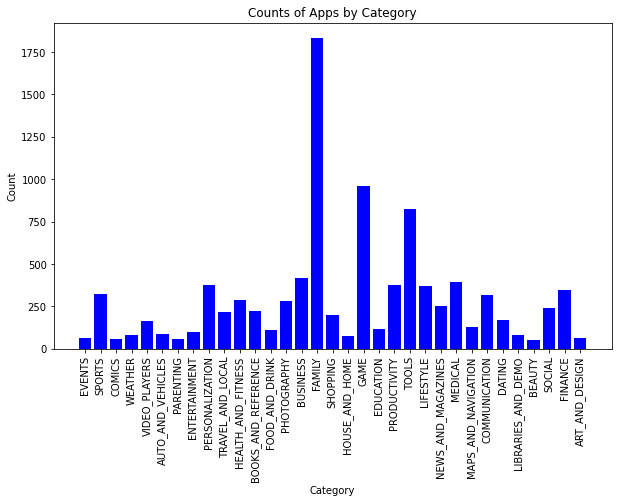

In [0]:
# Collect the counts for each category
category_counts = df_spark.groupBy('category').count().collect()

# Extract categories and counts from collected data
categories = [row['category'] for row in category_counts]
counts = [row['count'] for row in category_counts]

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(categories, counts, color='blue')
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Counts of Apps by Category')
plt.xticks(rotation=90)
plt.show()

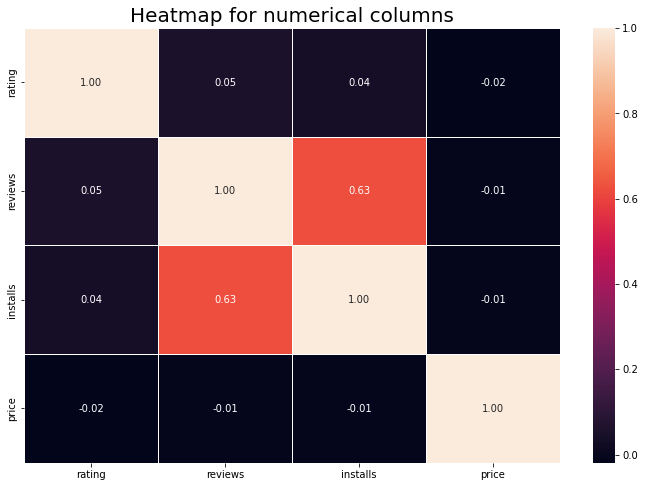

In [0]:
# Convert PySpark DataFrame to Pandas DataFrame
df_pandas = df_spark.toPandas()

# Plot heatmap for numerical columns
plt.figure(figsize=(12, 8))
sns.heatmap(df_pandas.corr(), annot=True, linewidths=0.5, fmt=".2f")
plt.title("Heatmap for numerical columns", size=20)
plt.show()

In [0]:
df_spark.write.saveAsTable("Google_Cleaned_Data" , mode='overwrite')

In [0]:
df_spark.is_cached

Out[25]: False

In [0]:
df_spark.persist()

Out[26]: DataFrame[app: string, category: string, rating: double, reviews: int, size_MB: string, installs: int, type: string, price: float, content_rating: string, genres: string, last_updated: string, current_ver: string, android_ver: string]

In [0]:
df_spark.is_cached

Out[27]: True

In [0]:
# Register the DataFrame as a temporary view
df_spark.createOrReplaceTempView("view_google_play_store")

In [0]:
%sql
SHOW TABLES

database,tableName,isTemporary
default,google_cleaned_data,false
,view_google_play_store,true


In [0]:
spark.sql("describe view_google_play_store").show(50)

+--------------+---------+-------+
|      col_name|data_type|comment|
+--------------+---------+-------+
|           app|   string|   null|
|      category|   string|   null|
|        rating|   double|   null|
|       reviews|      int|   null|
|       size_MB|   string|   null|
|      installs|      int|   null|
|          type|   string|   null|
|         price|    float|   null|
|content_rating|   string|   null|
|        genres|   string|   null|
|  last_updated|   string|   null|
|   current_ver|   string|   null|
|   android_ver|   string|   null|
+--------------+---------+-------+



In [0]:
# Execute the SQL query and display the results
spark.sql("SELECT * FROM view_google_play_store").show()

+--------------------+-------------------+------+--------+------------------+---------+----+-----+--------------+--------------------+------------------+------------------+------------------+
|                 app|           category|rating| reviews|           size_MB| installs|type|price|content_rating|              genres|      last_updated|       current_ver|       android_ver|
+--------------------+-------------------+------+--------+------------------+---------+----+-----+--------------+--------------------+------------------+------------------+------------------+
|            Township|             FAMILY|   4.6| 4451317|Varies with device| 50000000|Free|  0.0|      Everyone|              Casual|     July 19, 2018|             5.9.0|      4.0.3 and up|
|      Cathay Pacific|   TRAVEL_AND_LOCAL|   3.3|    4069|              50.0|  1000000|Free|  0.0|      Everyone|      Travel & Local|     July 25, 2018|             6.6.1|        4.3 and up|
|            Dr. 2048|             FAMIL

In [0]:
# 1. Count the number of apps in each category:
spark.sql("SELECT category, COUNT(*) AS count FROM view_google_play_store GROUP BY category ORDER BY count DESC").show()

+-------------------+-----+
|           category|count|
+-------------------+-----+
|             FAMILY| 1832|
|               GAME|  959|
|              TOOLS|  827|
|           BUSINESS|  420|
|            MEDICAL|  395|
|    PERSONALIZATION|  376|
|       PRODUCTIVITY|  374|
|          LIFESTYLE|  369|
|            FINANCE|  345|
|             SPORTS|  325|
|      COMMUNICATION|  315|
| HEALTH_AND_FITNESS|  287|
|        PHOTOGRAPHY|  281|
| NEWS_AND_MAGAZINES|  254|
|             SOCIAL|  239|
|BOOKS_AND_REFERENCE|  222|
|   TRAVEL_AND_LOCAL|  219|
|           SHOPPING|  202|
|             DATING|  171|
|      VIDEO_PLAYERS|  163|
+-------------------+-----+
only showing top 20 rows



In [0]:
#2. Find the top 10 most reviewed apps:
spark.sql("SELECT app, reviews FROM view_google_play_store ORDER BY reviews DESC LIMIT 10").show()

+--------------------+--------+
|                 app| reviews|
+--------------------+--------+
|            Facebook|78158306|
|  WhatsApp Messenger|69119316|
|           Instagram|66577313|
|Messenger – Text ...|56642847|
|      Clash of Clans|44891723|
|Clean Master- Spa...|42916526|
|      Subway Surfers|27722264|
|             YouTube|25655305|
|Security Master -...|24900999|
|        Clash Royale|23133508|
+--------------------+--------+



In [0]:
#3. Count the number of apps for each content rating:
spark.sql("SELECT content_rating, COUNT(*) AS count FROM view_google_play_store GROUP BY content_rating ORDER BY count DESC").show()

+---------------+-----+
| content_rating|count|
+---------------+-----+
|       Everyone| 7901|
|           Teen| 1036|
|     Mature 17+|  392|
|   Everyone 10+|  322|
|Adults only 18+|    3|
|        Unrated|    2|
+---------------+-----+



In [0]:
#4. Find the top 10 categories with the highest number of installs:
spark.sql("SELECT category, SUM(CAST(installs AS INT)) AS total_installs FROM view_google_play_store GROUP BY category ORDER BY total_installs DESC LIMIT 10").show()

+------------------+--------------+
|          category|total_installs|
+------------------+--------------+
|              GAME|   13878924415|
|     COMMUNICATION|   11038276251|
|             TOOLS|    8001771915|
|      PRODUCTIVITY|    5793091369|
|            SOCIAL|    5487867902|
|       PHOTOGRAPHY|    4649147655|
|            FAMILY|    4427941505|
|     VIDEO_PLAYERS|    3926902720|
|  TRAVEL_AND_LOCAL|    2894887146|
|NEWS_AND_MAGAZINES|    2369217760|
+------------------+--------------+



In [0]:
#5
spark.sql("SELECT * FROM view_google_play_store WHERE category = 'GAME' AND type = 'Free'").show()

+--------------------+--------+------+-------+------------------+---------+----+-----+--------------+---------+------------------+------------------+------------------+
|                 app|category|rating|reviews|           size_MB| installs|type|price|content_rating|   genres|      last_updated|       current_ver|       android_ver|
+--------------------+--------+------+-------+------------------+---------+----+-----+--------------+---------+------------------+------------------+------------------+
|      Merge Dragons!|    GAME|   4.5| 214777|              91.0|  5000000|Free|  0.0|      Everyone|   Puzzle|     July 30, 2018|             3.6.0|        4.1 and up|
|Fancy Pants Adven...|    GAME|   4.7|  55952|              61.0|  1000000|Free|  0.0|  Everyone 10+|   Arcade|     July 13, 2017|            1.0.10|        4.1 and up|
|        Dr. Dominoes|    GAME|   4.0|   2700|               5.0|   500000|Free|  0.0|      Everyone|    Board|   January 3, 2018|              1.06|      

In [0]:
#5.1 Subquery to find the average rating of free games:
spark.sql("""
          SELECT ROUND(AVG(rating), 1) AS avg_rating_free_games 
          FROM (SELECT * 
                FROM view_google_play_store 
                WHERE category = 'GAME' AND type = 'Free')
          """).show()

+---------------------+
|avg_rating_free_games|
+---------------------+
|                  4.2|
+---------------------+



In [0]:
#5.2 Subquery to find the total number of reviews for paid games:
spark.sql("""
          SELECT SUM(reviews) AS total_reviews_paid_games 
          FROM (SELECT * 
                FROM view_google_play_store 
                WHERE category = 'GAME' AND type = 'Paid')
          """).show()

+------------------------+
|total_reviews_paid_games|
+------------------------+
|                 1572851|
+------------------------+



In [0]:
#5.3 Subquery to Retrieve Top 10 Most Popular Games with Highest Ratings:
spark.sql("""
          SELECT app, MAX(reviews) AS max_reviews, MAX(rating) AS max_rating
          FROM view_google_play_store 
          WHERE category = 'GAME'
          GROUP BY app
          ORDER BY max_reviews DESC
          LIMIT 10
          """).show()

+--------------------+-----------+----------+
|                 app|max_reviews|max_rating|
+--------------------+-----------+----------+
|      Clash of Clans|   44891723|       4.6|
|      Subway Surfers|   27722264|       4.5|
|        Clash Royale|   23133508|       4.6|
|    Candy Crush Saga|   22426677|       4.4|
|      My Talking Tom|   14891223|       4.5|
|         8 Ball Pool|   14198297|       4.5|
|      Shadow Fight 2|   10979062|       4.6|
|                 Pou|   10485308|       4.3|
|          Pokémon GO|   10424925|       4.1|
|Minion Rush: Desp...|   10216538|       4.5|
+--------------------+-----------+----------+

